# GO2 IMU Polynomial Velocity Model

Fits a polynomial mapping from the GO2's **onboard IMU-reported velocities**
`(sport_vx, sport_vy, sport_vyaw)` to **OptiTrack ground-truth body-frame velocities**.

## Goal
The GO2's sport-mode odometry accumulates drift due to leg slip, IMU bias,
and kinematic model inaccuracies. This notebook learns a polynomial
correction:
$$
\hat{v}^\text{true} = f_\theta(v^\text{IMU}), \quad
f_\theta \in \mathbb{R}[v_x, v_y, \dot\psi]_{\deg \le 2}
$$
for each of the three velocity components.

## Data
* **Input** – `go2/dataset/data_rigid_bodies*.csv`  
  Synchronized GO2 sport-mode state + OptiTrack rigid-body measurements.
* **Ground truth** – OptiTrack position / quaternion → finite-difference velocity,
  rotated into the robot body frame using the IMU heading.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

# ── configuration ───────────────────────────────────────────────────────────
DATASET_DIR  = Path("go2/dataset")
POLY_DEGREE  = 2      # polynomial degree for regression
RIDGE_ALPHA  = 1e-3   # Ridge regularisation
DT_MAX_SEC   = 0.5    # drop increments with dt > this (sync gaps)
VEL_CLIP_MS  = 5.0    # clip extreme translational velocities (m/s)
VYAW_CLIP    = 10.0   # clip extreme yaw-rate values (rad/s)

rng = np.random.default_rng(0)

## 1  Coordinate-frame helpers

**OptiTrack** records positions in a *world* frame aligned during capture.
From `plot_position_comparison.py` the mapping to the sport-mode world frame is:
```
opti_x_world = −rigid_y
opti_y_world =  rigid_x
```
Yaw is extracted from the rigid-body quaternion using the standard ZYX
Euler decomposition and then aligned to the IMU heading at the start of
each recording.

In [2]:
def wrap_pi(x: np.ndarray) -> np.ndarray:
    """Wrap angle(s) to (−π, π]."""
    return (x + np.pi) % (2 * np.pi) - np.pi


def optitrack_yaw(qx, qy, qz, qw) -> np.ndarray:
    """
    Yaw (rotation about vertical Z) from OptiTrack quaternion.
    Standard ZYX Euler decomposition:
        yaw = atan2(2(qw·qz + qx·qy), 1 − 2(qy² + qz²))
    """
    return np.arctan2(
        2 * (qw * qz + qx * qy),
        1 - 2 * (qy**2 + qz**2),
    )


def world_to_body(dx_w, dy_w, heading_rad) -> tuple:
    """
    Rotate a world-frame 2-D displacement into the robot body frame.

    Body-frame axes: x forward, y left.  Heading θ is the angle from
    world-x to body-x, positive counter-clockwise.

        [dx_b]   [ cos θ   sin θ ] [dx_w]
        [dy_b] = [−sin θ   cos θ ] [dy_w]
    """
    c, s = np.cos(heading_rad), np.sin(heading_rad)
    return c * dx_w + s * dy_w, -s * dx_w + c * dy_w

## 2  Load and process all recordings

For each CSV:
1. Convert timestamps to relative seconds.
2. Compute OptiTrack world-frame positions (zeroed at first sample).
3. Extract and align yaw from quaternion.
4. For each consecutive pair of rows compute:
   * `dt` from `sample_ts_ns`
   * world-frame OptiTrack displacement → body-frame → **true velocity**
   * **IMU velocity** = `sport_vx / vy / vyaw` at the earlier sample

In [3]:
def load_recording(csv_path: Path) -> pd.DataFrame | None:
    """Load one CSV and return a DataFrame of per-step velocity pairs."""
    df = pd.read_csv(csv_path)
    if len(df) < 10:
        return None

    # ── time ────────────────────────────────────────────────────────────────
    t = df["sample_ts_ns"].values / 1e9
    t -= t[0]

    # ── OptiTrack world-frame position (zeroed) ──────────────────────────────
    ox = -df["rigid_y"].values;  ox -= ox[0]
    oy =  df["rigid_x"].values;  oy -= oy[0]

    # ── yaw from quaternion, aligned to IMU heading at t=0 ─────────────────
    oyaw  = optitrack_yaw(
        df["rigid_qx"].values, df["rigid_qy"].values,
        df["rigid_qz"].values, df["rigid_qw"].values,
    )
    yaw0  = df["sport_heading"].values[0] - oyaw[0]
    oyaw  = wrap_pi(oyaw + yaw0)

    imu_heading = df["sport_heading"].values
    imu_vx      = df["sport_vx"].values
    imu_vy      = df["sport_vy"].values
    imu_vyaw    = df["sport_vyaw"].values

    # ── per-step increments ─────────────────────────────────────────────────
    rows = []
    for i in range(len(t) - 1):
        dt = t[i + 1] - t[i]
        if dt <= 0:
            continue

        d_ox   = ox[i + 1]   - ox[i]
        d_oy   = oy[i + 1]   - oy[i]
        d_oyaw = wrap_pi(oyaw[i + 1] - oyaw[i])

        # world → body frame using IMU heading at start of interval
        d_bx, d_by = world_to_body(d_ox, d_oy, imu_heading[i])

        rows.append({
            "imu_vx":   imu_vx[i],
            "imu_vy":   imu_vy[i],
            "imu_vyaw": imu_vyaw[i],
            "true_vx":  d_bx / dt,
            "true_vy":  d_by / dt,
            "true_vyaw": d_oyaw / dt,
            "dt":       dt,
        })

    seg = pd.DataFrame(rows)
    seg["recording"] = csv_path.stem
    return seg


# ── load all recordings ──────────────────────────────────────────────────────
csv_files = sorted(DATASET_DIR.glob("data_rigid_bodies*.csv"))
print(f"Found {len(csv_files)} CSV files\n")

segments = []
for f in csv_files:
    seg = load_recording(f)
    if seg is not None:
        segments.append(seg)
        print(f"  {f.name:55s}  {len(seg):>4d} increments")

raw = pd.concat(segments, ignore_index=True)
print(f"\nTotal increments (raw): {len(raw)}")

Found 13 CSV files

  data_rigid_bodies.csv                                     895 increments
  data_rigid_bodies_2026-02-19_15-20-05.csv                 656 increments
  data_rigid_bodies_2026-02-19_15-26-49.csv                 275 increments
  data_rigid_bodies_2026-02-19_15-58-52.csv                 155 increments
  data_rigid_bodies_2026-02-19_16-00-08.csv                 213 increments
  data_rigid_bodies_2026-02-19_16-01-52.csv                 410 increments
  data_rigid_bodies_2026-02-19_16-03-35.csv                 386 increments
  data_rigid_bodies_2026-02-19_16-04-44.csv                 150 increments
  data_rigid_bodies_2026-02-19_16-05-38.csv                 330 increments
  data_rigid_bodies_2026-02-19_16-06-39.csv                 343 increments
  data_rigid_bodies_2026-02-19_16-07-52.csv                 407 increments
  data_rigid_bodies_2026-02-19_16-09-39.csv                1006 increments

Total increments (raw): 5226


## 3  Data cleaning

Remove rows where:
* `dt > DT_MAX_SEC` — timestamp jump indicating a dropped packet / sync gap.
* `|true_vx|` or `|true_vy| > VEL_CLIP_MS` — likely noise spike from a
  single-step position outlier.
* `|true_vyaw| > VYAW_CLIP` — same for yaw rate.

In [4]:
mask = (
    (raw["dt"]         < DT_MAX_SEC)  &
    (raw["true_vx"].abs()   < VEL_CLIP_MS) &
    (raw["true_vy"].abs()   < VEL_CLIP_MS) &
    (raw["true_vyaw"].abs() < VYAW_CLIP)
)
data = raw[mask].copy().reset_index(drop=True)
print(f"Retained {mask.sum()} / {len(mask)} increments after cleaning")
print(f"Recordings: {data['recording'].nunique()}")
data[["imu_vx","imu_vy","imu_vyaw","true_vx","true_vy","true_vyaw","dt"]].describe().round(5)

Retained 5222 / 5226 increments after cleaning
Recordings: 12


,imu_vx,imu_vy,imu_vyaw,true_vx,true_vy,true_vyaw,dt
count,5222.00000,5222.00000,5222.00000,5222.00000,5222.00000,5222.00000,5222.00000
mean,0.09861,-0.01098,-0.00147,0.08076,0.00346,0.00223,0.09802
std,0.29613,0.23022,0.60076,0.34798,0.26861,0.57819,0.03398
min,-1.01709,-2.08050,-2.91350,-1.13538,-1.03928,-2.34689,0.00020
25%,-0.00000,-0.01881,-0.02770,-0.00303,-0.02659,-0.02352,0.10022
50%,0.00076,0.00000,0.00320,0.00086,0.00009,0.00121,0.10567
75%,0.16359,0.01820,0.05859,0.15868,0.03185,0.04787,0.11953
max,1.64744,1.04599,2.35317,1.20798,0.98695,2.17492,0.36002


## 4  Exploratory analysis

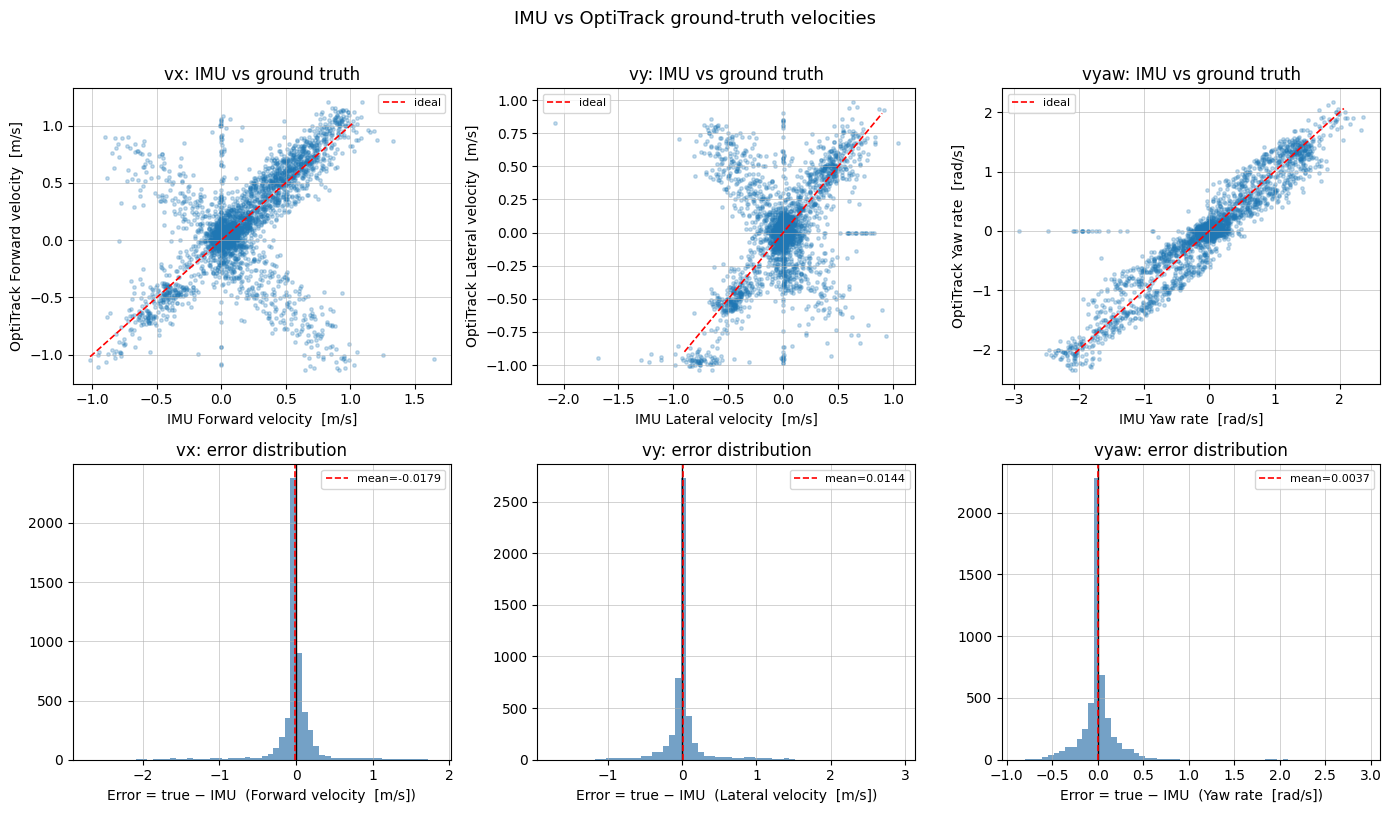

In [5]:
channels = [
    ("vx",   "imu_vx",   "true_vx",   "Forward velocity  [m/s]"),
    ("vy",   "imu_vy",   "true_vy",   "Lateral velocity  [m/s]"),
    ("vyaw", "imu_vyaw", "true_vyaw", "Yaw rate  [rad/s]"),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("IMU vs OptiTrack ground-truth velocities", fontsize=13, y=1.01)

for col, (key, imu_col, true_col, ylabel) in enumerate(channels):
    imu  = data[imu_col].values
    true = data[true_col].values
    err  = true - imu

    # scatter: IMU vs true
    ax = axes[0, col]
    ax.scatter(imu, true, alpha=0.25, s=6, rasterized=True)
    lim = np.quantile(np.abs(np.concatenate([imu, true])), 0.99)
    ax.plot([-lim, lim], [-lim, lim], "r--", lw=1.2, label="ideal")
    ax.set_xlabel(f"IMU {ylabel}")
    ax.set_ylabel(f"OptiTrack {ylabel}")
    ax.set_title(f"{key}: IMU vs ground truth")
    ax.legend(fontsize=8)
    ax.grid(True, lw=0.4)

    # histogram of error
    ax2 = axes[1, col]
    ax2.hist(err, bins=60, color="steelblue", edgecolor="none", alpha=0.75)
    ax2.axvline(0, color="k", lw=1)
    ax2.axvline(err.mean(), color="red", lw=1.2, linestyle="--",
                label=f"mean={err.mean():.4f}")
    ax2.set_xlabel(f"Error = true − IMU  ({ylabel})")
    ax2.set_title(f"{key}: error distribution")
    ax2.legend(fontsize=8)
    ax2.grid(True, lw=0.4)

plt.tight_layout()
plt.show()

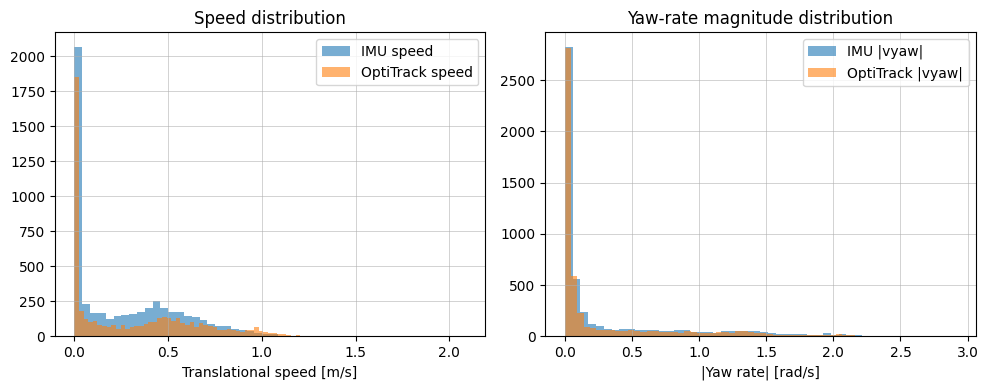

In [6]:
# ── velocity magnitude histogram ─────────────────────────────────────────────
speed_imu  = np.hypot(data["imu_vx"],  data["imu_vy"])
speed_true = np.hypot(data["true_vx"], data["true_vy"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(speed_imu,  bins=50, alpha=0.6, label="IMU speed")
axes[0].hist(speed_true, bins=50, alpha=0.6, label="OptiTrack speed")
axes[0].set_xlabel("Translational speed [m/s]")
axes[0].set_title("Speed distribution")
axes[0].legend()
axes[0].grid(True, lw=0.4)

axes[1].hist(data["imu_vyaw"].abs(), bins=50, alpha=0.6, label="IMU |vyaw|")
axes[1].hist(data["true_vyaw"].abs(), bins=50, alpha=0.6, label="OptiTrack |vyaw|")
axes[1].set_xlabel("|Yaw rate| [rad/s]")
axes[1].set_title("Yaw-rate magnitude distribution")
axes[1].legend()
axes[1].grid(True, lw=0.4)

plt.tight_layout()
plt.show()

## 5  Polynomial regression

### Feature space

For degree $d = 2$ the feature vector $\phi$ expanded from
$(v_x^\text{imu},\, v_y^\text{imu},\, \dot\psi^\text{imu})$ is:

$$
\phi = \bigl[1,\; v_x,\; v_y,\; \dot\psi,\;
             v_x^2,\; v_x v_y,\; v_x\dot\psi,\;
             v_y^2,\; v_y\dot\psi,\;
             \dot\psi^2 \bigr] \in \mathbb{R}^{10}
$$

Three independent Ridge regression models are fit:
$$
\hat v_x^\text{true} = \theta_x^\top \phi, \quad
\hat v_y^\text{true} = \theta_y^\top \phi, \quad
\hat{\dot\psi}^\text{true} = \theta_\psi^\top \phi
$$

In [7]:
X = data[["imu_vx", "imu_vy", "imu_vyaw"]].values          # (N, 3)
Y = data[["true_vx", "true_vy", "true_vyaw"]].values       # (N, 3)

target_names = ["vx", "vy", "vyaw"]

# ── fit ─────────────────────────────────────────────────────────────────────
models = {}
for i, tgt in enumerate(target_names):
    pipe = make_pipeline(
        PolynomialFeatures(degree=POLY_DEGREE, include_bias=True),
        Ridge(alpha=RIDGE_ALPHA),
    )
    pipe.fit(X, Y[:, i])
    models[tgt] = pipe

print(f"Polynomial degree : {POLY_DEGREE}")
print(f"Number of features: "
      f"{models['vx'].named_steps['polynomialfeatures'].n_output_features_}")
print(f"Ridge alpha       : {RIDGE_ALPHA}")

Polynomial degree : 2
Number of features: 10
Ridge alpha       : 0.001


## 6  In-sample evaluation

In [8]:
results = {}

print(f"{'Channel':>8}  {'R²_poly':>8}  {'RMSE_poly':>10}  "
      f"{'R²_imu':>8}  {'RMSE_imu':>10}  (improvement)")
print("-" * 72)

for i, tgt in enumerate(target_names):
    y_true  = Y[:, i]
    y_pred  = models[tgt].predict(X)
    y_imu   = X[:, i]         # raw IMU as naive baseline

    r2_poly = r2_score(y_true, y_pred)
    r2_imu  = r2_score(y_true, y_imu)
    rmse_p  = np.sqrt(np.mean((y_true - y_pred)**2))
    rmse_i  = np.sqrt(np.mean((y_true - y_imu )**2))

    results[tgt] = dict(y_true=y_true, y_pred=y_pred, y_imu=y_imu,
                        r2_poly=r2_poly, rmse_poly=rmse_p,
                        r2_imu=r2_imu,  rmse_imu=rmse_i)

    pct = 100 * (rmse_i - rmse_p) / (rmse_i + 1e-12)
    print(f"{tgt:>8}  {r2_poly:>8.4f}  {rmse_p:>10.5f}  "
          f"{r2_imu:>8.4f}  {rmse_i:>10.5f}  ({pct:+.1f}%)")

 Channel   R²_poly   RMSE_poly    R²_imu    RMSE_imu  (improvement)
------------------------------------------------------------------------
      vx    0.3602     0.27831    0.1415     0.32238  (+13.7%)
      vy    0.2084     0.23896   -0.0562     0.27602  (+13.4%)
    vyaw    0.8996     0.18320    0.8777     0.20218  (+9.4%)


## 7  Cross-validation by recording

Each recording is an independent experiment; we use
`GroupKFold` so that no recording appears in both train and
validation within a fold.

In [9]:
groups = pd.factorize(data["recording"])[0]
n_groups = len(np.unique(groups))
n_splits = min(5, n_groups)
gkf = GroupKFold(n_splits=n_splits)

print(f"GroupKFold with {n_splits} splits over {n_groups} recordings\n")
print(f"{'Channel':>8}  {'CV R² mean':>12}  {'CV R² std':>10}")
print("-" * 38)

for i, tgt in enumerate(target_names):
    pipe = make_pipeline(
        PolynomialFeatures(degree=POLY_DEGREE, include_bias=True),
        Ridge(alpha=RIDGE_ALPHA),
    )
    cv = cross_val_score(pipe, X, Y[:, i],
                         cv=gkf, groups=groups, scoring="r2")
    print(f"{tgt:>8}  {cv.mean():>12.4f}  {cv.std():>10.4f}")

GroupKFold with 5 splits over 12 recordings

 Channel    CV R² mean   CV R² std
--------------------------------------
      vx        0.0950      0.5340
      vy       -0.5384      0.6926
    vyaw       -0.4722      2.5484


## 8  Fitted polynomial coefficients

Interpret the learned corrections:
* **Degree-1 terms** — scale factors and bias corrections.
* **Degree-2 cross-terms** — coupling between axes (e.g. does yawing
  distort the forward velocity estimate?).

In [10]:
feat_names = (
    PolynomialFeatures(degree=POLY_DEGREE, include_bias=True)
    .fit(X)
    .get_feature_names_out(["vx", "vy", "vyaw"])
)

for tgt in target_names:
    coefs = models[tgt].named_steps["ridge"].coef_
    bias  = models[tgt].named_steps["ridge"].intercept_
    df_c  = pd.DataFrame({"feature": feat_names, "coef": coefs})
    df_c  = df_c.reindex(df_c["coef"].abs().sort_values(ascending=False).index)

    print(f"\n── f_{tgt}  (bias = {bias:.6f}) ─────────────────────")
    print(df_c.to_string(index=False, float_format="{:+.6f}".format))


── f_vx  (bias = 0.019924) ─────────────────────
feature      coef
  vx vy +0.663887
     vx +0.530235
vx vyaw +0.337903
   vx^2 -0.157389
     vy -0.076054
   vyaw +0.065376
vy vyaw -0.053432
 vyaw^2 +0.033998
   vy^2 -0.022818
      1 +0.000000

── f_vy  (bias = 0.023995) ─────────────────────
feature      coef
     vy +0.455505
   vy^2 +0.269394
     vx -0.092610
vx vyaw -0.051801
 vyaw^2 -0.046223
   vyaw +0.033581
vy vyaw -0.023157
   vx^2 -0.008251
  vx vy +0.003512
      1 +0.000000

── f_vyaw  (bias = -0.008382) ─────────────────────
feature      coef
   vyaw +0.891435
vy vyaw -0.243875
   vy^2 +0.133051
     vy +0.105097
  vx vy +0.066276
 vyaw^2 +0.051334
vx vyaw -0.022063
     vx +0.011368
   vx^2 +0.011171
      1 +0.000000


## 9  Visualisation of model fit

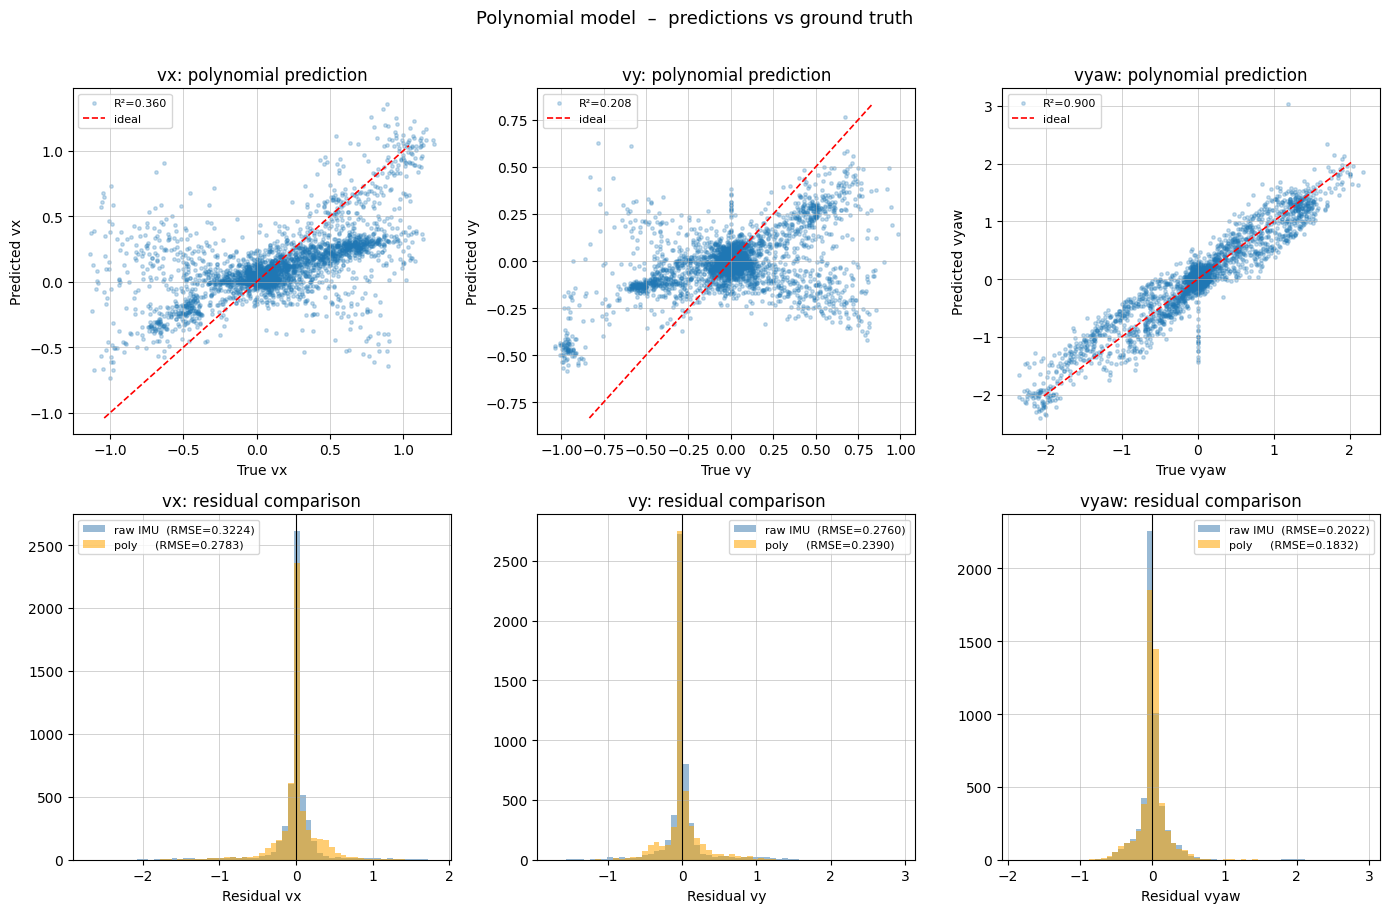

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle("Polynomial model  –  predictions vs ground truth",
             fontsize=13, y=1.01)

for col, tgt in enumerate(target_names):
    r = results[tgt]

    # ── scatter: predicted vs true ───────────────────────────────────────────
    ax = axes[0, col]
    lim = np.quantile(np.abs(np.concatenate([r["y_true"], r["y_pred"]])), 0.99)
    ax.scatter(r["y_true"], r["y_pred"], alpha=0.25, s=6, rasterized=True,
               label=f"R²={r['r2_poly']:.3f}")
    ax.plot([-lim, lim], [-lim, lim], "r--", lw=1.2, label="ideal")
    ax.set_xlabel(f"True {tgt}")
    ax.set_ylabel(f"Predicted {tgt}")
    ax.set_title(f"{tgt}: polynomial prediction")
    ax.legend(fontsize=8)
    ax.grid(True, lw=0.4)

    # ── residual comparison ──────────────────────────────────────────────────
    ax2 = axes[1, col]
    res_imu  = r["y_true"] - r["y_imu"]
    res_poly = r["y_true"] - r["y_pred"]
    bins = np.linspace(
        min(res_imu.min(), res_poly.min()),
        max(res_imu.max(), res_poly.max()), 60)
    ax2.hist(res_imu,  bins=bins, alpha=0.55, color="steelblue",
             label=f"raw IMU  (RMSE={r['rmse_imu']:.4f})")
    ax2.hist(res_poly, bins=bins, alpha=0.55, color="orange",
             label=f"poly     (RMSE={r['rmse_poly']:.4f})")
    ax2.axvline(0, color="k", lw=0.8)
    ax2.set_xlabel(f"Residual {tgt}")
    ax2.set_title(f"{tgt}: residual comparison")
    ax2.legend(fontsize=8)
    ax2.grid(True, lw=0.4)

plt.tight_layout()
plt.show()

## 10  Velocity-dependent error heat-maps

Show how the IMU error varies with the commanded speed magnitude and
yaw rate – useful for checking where the polynomial fit matters most.

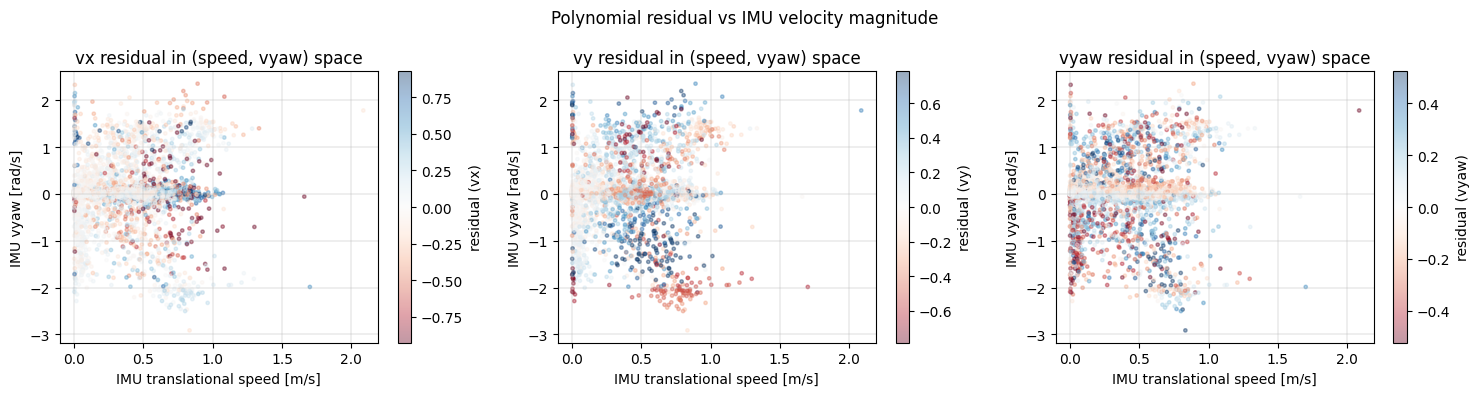

In [12]:
speed = np.hypot(data["imu_vx"].values, data["imu_vy"].values)
vyaw  = data["imu_vyaw"].values.copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Polynomial residual vs IMU velocity magnitude", fontsize=12)

for col, tgt in enumerate(target_names):
    res  = results[tgt]["y_true"] - results[tgt]["y_pred"]
    sc = axes[col].scatter(speed, vyaw, c=res, cmap="RdBu",
                           vmin=-np.quantile(np.abs(res), 0.98),
                           vmax= np.quantile(np.abs(res), 0.98),
                           alpha=0.4, s=6, rasterized=True)
    plt.colorbar(sc, ax=axes[col], label=f"residual ({tgt})")
    axes[col].set_xlabel("IMU translational speed [m/s]")
    axes[col].set_ylabel("IMU vyaw [rad/s]")
    axes[col].set_title(f"{tgt} residual in (speed, vyaw) space")
    axes[col].grid(True, lw=0.3)

plt.tight_layout()
plt.show()

## 11  Trajectory integration comparison

Integrate velocities forward from the start of one long recording and
compare the resulting trajectory to OptiTrack ground truth.  This
illustrates the cumulative effect of IMU bias and the polynomial correction.

Demo recording: data_rigid_bodies_2026-02-19_16-09-39  (1006 steps)


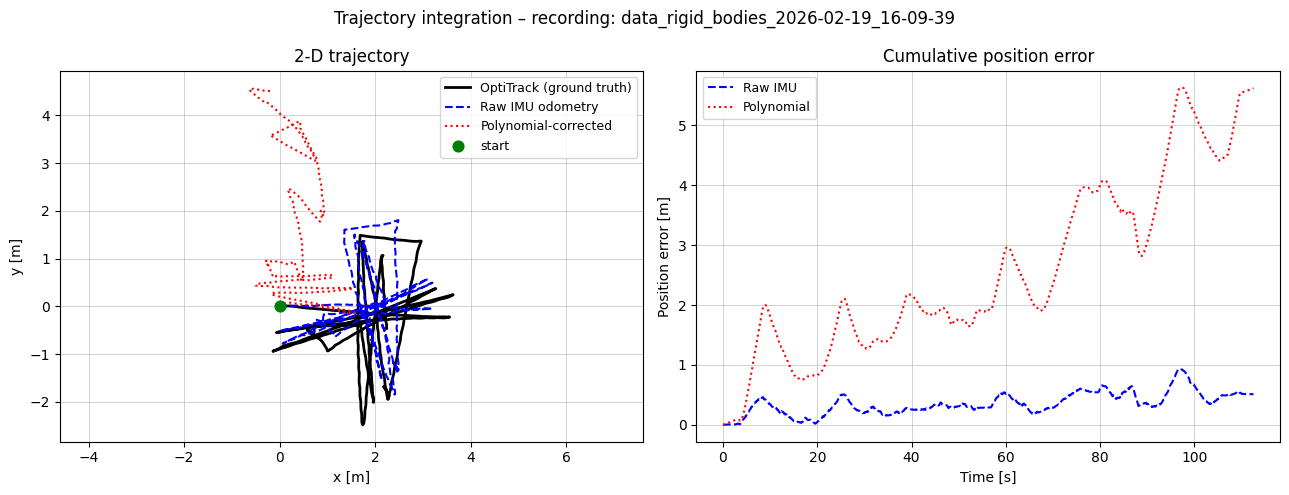


Final position error:
  Raw IMU    : 0.5120 m
  Polynomial : 5.6212 m


In [13]:
# pick the recording with the most increments as the demo trajectory
rec_counts = data.groupby("recording").size()
demo_rec   = rec_counts.idxmax()
seg        = data[data["recording"] == demo_rec].copy().reset_index(drop=True)
print(f"Demo recording: {demo_rec}  ({len(seg)} steps)")

# ground-truth trajectory from OptiTrack increments
# (re-derive from processed data; body increments → world frame)

def integrate_velocity(vx_body, vy_body, vyaw, dt_arr):
    """
    Euler-integrate body-frame velocities to get a world-frame trajectory.
    Returns arrays of (x, y, heading).
    """
    x, y, h = 0.0, 0.0, 0.0
    xs, ys, hs = [x], [y], [h]
    for vx, vy, vyaw_k, dt in zip(vx_body, vy_body, vyaw, dt_arr):
        c, s = np.cos(h), np.sin(h)
        x += (c * vx - s * vy) * dt
        y += (s * vx + c * vy) * dt
        h  = wrap_pi(h + vyaw_k * dt)
        xs.append(x); ys.append(y); hs.append(h)
    return np.array(xs), np.array(ys), np.array(hs)

dt_arr = seg["dt"].values

# ── OptiTrack (ground truth via finite-difference increments) ────────────────
x_gt, y_gt, _ = integrate_velocity(
    seg["true_vx"].values, seg["true_vy"].values,
    seg["true_vyaw"].values, dt_arr)

# ── raw IMU odometry ─────────────────────────────────────────────────────────
x_imu, y_imu, _ = integrate_velocity(
    seg["imu_vx"].values, seg["imu_vy"].values,
    seg["imu_vyaw"].values, dt_arr)

# ── polynomial-corrected odometry ────────────────────────────────────────────
X_seg   = seg[["imu_vx", "imu_vy", "imu_vyaw"]].values
vx_poly = models["vx"].predict(X_seg)
vy_poly = models["vy"].predict(X_seg)
vw_poly = models["vyaw"].predict(X_seg)
x_poly, y_poly, _ = integrate_velocity(vx_poly, vy_poly, vw_poly, dt_arr)

# ── plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Trajectory integration – recording: {demo_rec}", fontsize=12)

ax = axes[0]
ax.plot(x_gt,   y_gt,   "k-",  lw=2,   label="OptiTrack (ground truth)")
ax.plot(x_imu,  y_imu,  "b--", lw=1.5, label="Raw IMU odometry")
ax.plot(x_poly, y_poly, "r:",  lw=1.5, label="Polynomial-corrected")
ax.scatter([0], [0], c="g", zorder=5, s=60, label="start")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("2-D trajectory")
ax.legend(fontsize=9)
ax.axis("equal")
ax.grid(True, lw=0.4)

# position error over time
T = np.concatenate([[0], np.cumsum(dt_arr)])
err_imu  = np.hypot(x_gt - x_imu,  y_gt - y_imu)
err_poly = np.hypot(x_gt - x_poly, y_gt - y_poly)

ax2 = axes[1]
ax2.plot(T, err_imu,  "b--", lw=1.5, label="Raw IMU")
ax2.plot(T, err_poly, "r:",  lw=1.5, label="Polynomial")
ax2.set_xlabel("Time [s]")
ax2.set_ylabel("Position error [m]")
ax2.set_title("Cumulative position error")
ax2.legend(fontsize=9)
ax2.grid(True, lw=0.4)

plt.tight_layout()
plt.show()

print(f"\nFinal position error:")
print(f"  Raw IMU    : {err_imu[-1]:.4f} m")
print(f"  Polynomial : {err_poly[-1]:.4f} m")

## 12  Polynomial model summary

Print the three polynomials in a human-readable form, sorted by
absolute coefficient magnitude.

In [14]:
print("Learned polynomial corrections  (sorted by |coef|)\n")
print("=" * 60)

for tgt in target_names:
    ridge  = models[tgt].named_steps["ridge"]
    coefs  = ridge.coef_
    bias   = ridge.intercept_

    df_c = pd.DataFrame({"term": feat_names, "coef": coefs})
    df_c = df_c.reindex(df_c["coef"].abs().sort_values(ascending=False).index)

    print(f"\nf_{tgt}(vx, vy, vyaw) = bias({bias:+.5f})")
    for _, row in df_c.iterrows():
        bar = "█" * int(min(30, 30 * abs(row["coef"]) / (df_c["coef"].abs().max() + 1e-12)))
        print(f"  {row['coef']:+.6f}  {row['term']:<18s}  {bar}")

print("\n" + "=" * 60)

Learned polynomial corrections  (sorted by |coef|)


f_vx(vx, vy, vyaw) = bias(+0.01992)
  +0.663887  vx vy               █████████████████████████████
  +0.530235  vx                  ███████████████████████
  +0.337903  vx vyaw             ███████████████
  -0.157389  vx^2                ███████
  -0.076054  vy                  ███
  +0.065376  vyaw                ██
  -0.053432  vy vyaw             ██
  +0.033998  vyaw^2              █
  -0.022818  vy^2                █
  +0.000000  1                   

f_vy(vx, vy, vyaw) = bias(+0.02400)
  +0.455505  vy                  █████████████████████████████
  +0.269394  vy^2                █████████████████
  -0.092610  vx                  ██████
  -0.051801  vx vyaw             ███
  -0.046223  vyaw^2              ███
  +0.033581  vyaw                ██
  -0.023157  vy vyaw             █
  -0.008251  vx^2                
  +0.003512  vx vy               
  +0.000000  1                   

f_vyaw(vx, vy, vyaw) = bias(-0.00838)
  +0.891435

## 13  Export model coefficients

Save the polynomial matrices as a NumPy archive for use in
downstream controllers or estimators.

In [15]:
out = {}
for tgt in target_names:
    ridge = models[tgt].named_steps["ridge"]
    out[f"coef_{tgt}"]      = ridge.coef_
    out[f"intercept_{tgt}"] = np.array([ridge.intercept_])

out["feature_names"] = np.array(feat_names)
out["poly_degree"]   = np.array([POLY_DEGREE])
out["ridge_alpha"]   = np.array([RIDGE_ALPHA])

save_path = Path("go2_velocity_poly_model.npz")
np.savez(save_path, **out)
print(f"Saved model to {save_path}")

# ── quick reload sanity check ────────────────────────────────────────────────
loaded = np.load(save_path, allow_pickle=True)
print("\nStored arrays:")
for k, v in loaded.items():
    print(f"  {k:<22s} shape={v.shape}")

Saved model to go2_velocity_poly_model.npz

Stored arrays:
  coef_vx                shape=(10,)
  intercept_vx           shape=(1,)
  coef_vy                shape=(10,)
  intercept_vy           shape=(1,)
  coef_vyaw              shape=(10,)
  intercept_vyaw         shape=(1,)
  feature_names          shape=(10,)
  poly_degree            shape=(1,)
  ridge_alpha            shape=(1,)


## 14  Conclusions

### What was fit

Three degree-2 polynomial Ridge regression models map the GO2 sport-mode
IMU velocity readings `(sport_vx, sport_vy, sport_vyaw)` to OptiTrack
ground-truth body-frame velocities:

```
true_vx   ≈ f_vx  (imu_vx, imu_vy, imu_vyaw)
true_vy   ≈ f_vy  (imu_vx, imu_vy, imu_vyaw)
true_vyaw ≈ f_vyaw(imu_vx, imu_vy, imu_vyaw)
```

### Interpretation

* **Degree-1 terms** reveal axis-wise scale-factor errors and any steady
  bias in the IMU velocity estimates.
* **Cross terms** (e.g. `vx·vyaw`) capture kinematic coupling: yawing while
  translating may cause the IMU to over/under-report velocity on one axis.
* **Degree-2 terms** model nonlinear velocity-dependent slip or sensor
  saturation effects.

### Limitations

* The polynomial is fit to the current dataset; it may not generalise to
  different surfaces or payloads.
* The OptiTrack-derived ground-truth velocity is a finite difference and
  inherits position noise; a Kalman-smoothed estimate would reduce label
  noise.
* High-degree polynomials can over-fit in regions with sparse data
  (e.g. large speeds); Ridge regularisation mitigates this but does not
  eliminate it.